# Conv1D Autoencoder with SWaT 2020

In [27]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from pathlib import Path

In [28]:
clean_folder = Path("SWaT.A7_June 2020_clean")
file_paths = sorted(clean_folder.glob("*.csv"))

print("Archivos encontrados:", len(file_paths))
for fp in file_paths:
    print(fp)

Archivos encontrados: 4
SWaT.A7_June 2020_clean\22June2020_1.csv
SWaT.A7_June 2020_clean\22June2020_2.csv
SWaT.A7_June 2020_clean\29June2020_1.csv
SWaT.A7_June 2020_clean\29June2020_2.csv


In [29]:
def load_clean_csv(path):
    df = pd.read_csv(path)
    
    timestamps = pd.to_datetime(df["t_stamp"], errors="coerce")
    df = df.drop(columns=["t_stamp"])
    
    df = df.ffill().bfill()
    
    return df, timestamps

In [30]:
dfs = []
timestamps_list = []

for fp in file_paths:
    df_i, ts_i = load_clean_csv(fp)
    dfs.append(df_i)
    timestamps_list.append(ts_i)

print("Número de archivos cargados:", len(dfs))
print("Shape archivo 1:", dfs[0].shape)

Número de archivos cargados: 4
Shape archivo 1: (14400, 60)


In [31]:
base_columns = dfs[0].columns.tolist()

for i, df_i in enumerate(dfs):
    assert df_i.columns.tolist() == base_columns, f"Columnas distintas en archivo {i}"

print("Todos los archivos tienen las mismas columnas.")
print("Número de variables:", len(base_columns))

Todos los archivos tienen las mismas columnas.
Número de variables: 60


In [32]:
def temporal_split(df, train_ratio=0.6, val_ratio=0.2):
    n = len(df)
    
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))
    
    train_df = df.iloc[:train_end].copy()
    val_df   = df.iloc[train_end:val_end].copy()
    test_df  = df.iloc[val_end:].copy()
    
    return train_df, val_df, test_df

In [33]:
train_parts = []
val_parts = []
test_parts = []

for i, df_i in enumerate(dfs):
    train_i, val_i, test_i = temporal_split(df_i, train_ratio=0.6, val_ratio=0.2)
    
    train_parts.append(train_i)
    val_parts.append(val_i)
    test_parts.append(test_i)
    
    print(f"Archivo {i+1}:")
    print("  train:", train_i.shape)
    print("  val:  ", val_i.shape)
    print("  test: ", test_i.shape)

train_df = pd.concat(train_parts, axis=0, ignore_index=True)
val_df   = pd.concat(val_parts, axis=0, ignore_index=True)
test_df  = pd.concat(test_parts, axis=0, ignore_index=True)

print("\nShapes finales:")
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Archivo 1:
  train: (8640, 60)
  val:   (2880, 60)
  test:  (2880, 60)
Archivo 2:
  train: (2160, 60)
  val:   (720, 60)
  test:  (720, 60)
Archivo 3:
  train: (4320, 60)
  val:   (1440, 60)
  test:  (1441, 60)
Archivo 4:
  train: (4320, 60)
  val:   (1440, 60)
  test:  (1441, 60)

Shapes finales:
Train: (19440, 60)
Validation: (6480, 60)
Test: (6482, 60)


In [34]:
scaler = StandardScaler()

train_scaled = scaler.fit_transform(train_df)
val_scaled   = scaler.transform(val_df)
test_scaled  = scaler.transform(test_df)

train_scaled = pd.DataFrame(train_scaled, columns=train_df.columns)
val_scaled   = pd.DataFrame(val_scaled, columns=val_df.columns)
test_scaled  = pd.DataFrame(test_scaled, columns=test_df.columns)

print(train_scaled.shape, val_scaled.shape, test_scaled.shape)

#revisar rangos de los datos standarizados
print("Rangos de los datos estandarizados:")
print("Train:")
print(train_scaled.min())
print(train_scaled.max())
print("\nValidation:")
print(val_scaled.min())
print(val_scaled.max())
print("\nTest:")
print(test_scaled.min())
print(test_scaled.max())

(19440, 60) (6480, 60) (6482, 60)
Rangos de los datos estandarizados:
Train:
P206.Status      0.000000
AIT202.Pv       -1.485089
P205.Status     -0.727505
P203.Status     -0.727505
FIT503.Pv       -0.972202
PIT501.Pv       -1.027992
FIT502.Pv       -0.960325
MV101.Status    -3.781013
P101.Status     -0.739200
AIT402.Pv        0.000000
P1_STATE        -1.476656
PIT503.Pv       -1.034250
MV503.Status    -6.388485
P502.Status      0.000000
P403.Status      0.000000
MV502.Status    -3.170484
P2_STATE        -1.811612
LIT101.Pv       -2.205941
P6_STATE        -1.811612
AIT503.Pv       -1.285859
P204.Status      0.000000
LIT301.Pv       -2.777047
AIT201.Pv       -1.000121
P5_STATE        -1.205668
PIT502.Pv       -0.827946
AIT502.Pv       -1.019876
AIT203.Pv       -4.624772
AIT501.Pv       -1.536202
MV504.Status    -6.099629
FIT301.Pv       -0.776929
MV302.Status    -2.783867
MV201.Status    -2.796644
P602.Status     -0.039965
MV303.Status   -13.255467
MV501.Status    -3.183036
LIT401.Pv    

In [10]:
def create_windows(data, window_size=60, stride=5):
    windows = []
    
    for i in range(0, len(data) - window_size, stride):
        window = data[i:i+window_size]
        windows.append(window)
    
    return np.array(windows)

In [11]:
L = 60
stride = 5

train_windows = create_windows(train_scaled.values, window_size=L, stride=stride)
val_windows   = create_windows(val_scaled.values, window_size=L, stride=stride)
test_windows  = create_windows(test_scaled.values, window_size=L, stride=stride)

print("Train windows:", train_windows.shape)
print("Validation windows:", val_windows.shape)
print("Test windows:", test_windows.shape)

Train windows: (3876, 60, 60)
Validation windows: (1284, 60, 60)
Test windows: (1285, 60, 60)


In [12]:
X_train = np.transpose(train_windows, (0, 2, 1))
X_val   = np.transpose(val_windows, (0, 2, 1))
X_test  = np.transpose(test_windows, (0, 2, 1))

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (3876, 60, 60)
X_val: (1284, 60, 60)
X_test: (1285, 60, 60)


In [13]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor   = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [14]:
class Conv1dAutoencoder(nn.Module):
    def __init__(self, input_channels=60):
        super(Conv1dAutoencoder, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels=input_channels, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),   # seq_len: 60 -> 30
            
            nn.Conv1d(in_channels=32, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)    # seq_len: 30 -> 15
        )
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(in_channels=16, out_channels=32, kernel_size=2, stride=2),  # 15 -> 30
            nn.ReLU(),
            
            nn.ConvTranspose1d(in_channels=32, out_channels=input_channels, kernel_size=2, stride=2),  # 30 -> 60
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

In [15]:
input_channels = X_train.shape[1]   # debería ser 60

model = Conv1dAutoencoder(input_channels=input_channels)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Device:", device)
print("Input channels:", input_channels)

Device: cpu
Input channels: 60


In [16]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 30
loss_history = []

In [17]:
for epoch in range(epochs):
    model.train()
    total_loss = 0
    
    for batch in train_loader:
        x = batch[0].to(device)
        
        optimizer.zero_grad()
        
        x_hat = model(x)
        loss = criterion(x_hat, x)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    epoch_loss = total_loss / len(train_loader)
    loss_history.append(epoch_loss)
    
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss}")

Epoch 1/30, Loss: 0.6313568935042522
Epoch 2/30, Loss: 0.3266872011247228
Epoch 3/30, Loss: 0.21950747316978017
Epoch 4/30, Loss: 0.16818497879583327
Epoch 5/30, Loss: 0.13238476509930658
Epoch 6/30, Loss: 0.11298906662669338
Epoch 7/30, Loss: 0.10514169082534118
Epoch 8/30, Loss: 0.09775313588439441
Epoch 9/30, Loss: 0.09043327889970092
Epoch 10/30, Loss: 0.08382945330660851
Epoch 11/30, Loss: 0.07650620084194863
Epoch 12/30, Loss: 0.06960743116062196
Epoch 13/30, Loss: 0.06470097787678242
Epoch 14/30, Loss: 0.06116740494111522
Epoch 15/30, Loss: 0.05961585336471679
Epoch 16/30, Loss: 0.05837081268918319
Epoch 17/30, Loss: 0.0539917544782406
Epoch 18/30, Loss: 0.05242088292038343
Epoch 19/30, Loss: 0.05058214982941014
Epoch 20/30, Loss: 0.04982508337277858
Epoch 21/30, Loss: 0.04834065143568594
Epoch 22/30, Loss: 0.04808988617580445
Epoch 23/30, Loss: 0.04655004184326676
Epoch 24/30, Loss: 0.04647878687218076
Epoch 25/30, Loss: 0.04559538383647555
Epoch 26/30, Loss: 0.0451093755021202

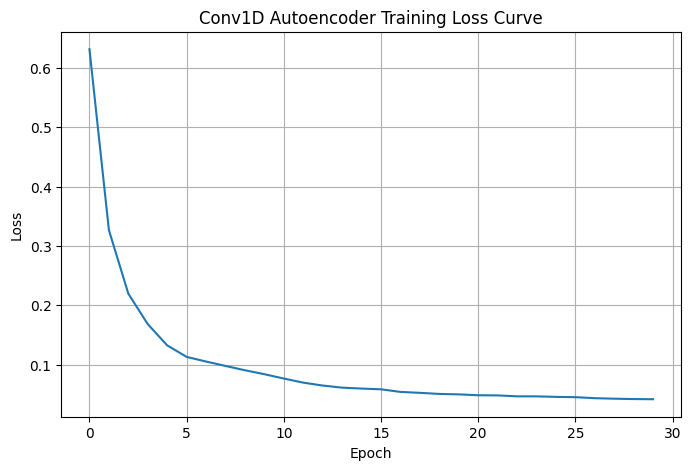

In [18]:
plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Conv1D Autoencoder Training Loss Curve")
plt.grid(True)
plt.show()

In [19]:
model.eval()

with torch.no_grad():
    x_val = X_val_tensor.to(device)
    x_val_hat = model(x_val)
    
    val_error = torch.mean((x_val - x_val_hat)**2, dim=(1, 2))
    val_reconstruction_errors = val_error.cpu().numpy()

In [20]:
with torch.no_grad():
    x_test = X_test_tensor.to(device)
    x_test_hat = model(x_test)
    
    test_error = torch.mean((x_test - x_test_hat)**2, dim=(1, 2))
    test_reconstruction_errors = test_error.cpu().numpy()

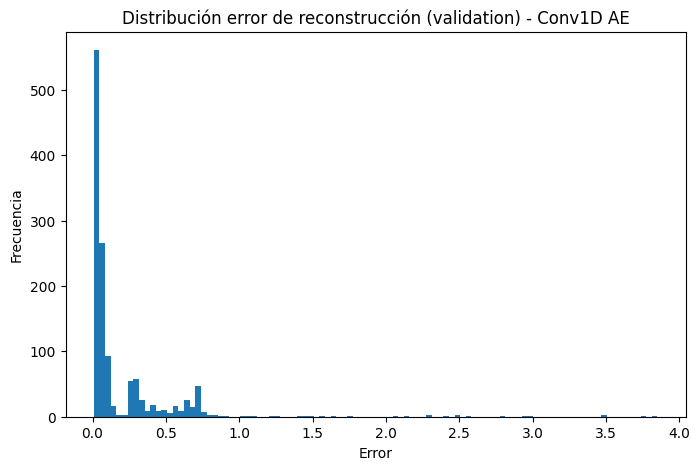

In [21]:
plt.figure(figsize=(8,5))
plt.hist(val_reconstruction_errors, bins=100)
plt.title("Distribución error de reconstrucción (validation) - Conv1D AE")
plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.show()

In [22]:
percentiles = np.percentile(val_reconstruction_errors, [90, 95, 97.5, 99])
print("P90, P95, P97.5, P99 =", percentiles)

P90, P95, P97.5, P99 = [0.60727308 0.72682733 0.78662314 2.18050358]


In [23]:
tau_95  = np.percentile(val_reconstruction_errors, 95)
tau_975 = np.percentile(val_reconstruction_errors, 97.5)
tau_99  = np.percentile(val_reconstruction_errors, 99)

print("tau_95 =", tau_95)
print("tau_97.5 =", tau_975)
print("tau_99 =", tau_99)

tau_95 = 0.7268273
tau_97.5 = 0.78662413
tau_99 = 2.1805098


In [24]:
far_95  = np.mean(test_reconstruction_errors > tau_95)
far_975 = np.mean(test_reconstruction_errors > tau_975)
far_99  = np.mean(test_reconstruction_errors > tau_99)

print("FAR @ P95:", far_95, "->", far_95 * 100, "%")
print("FAR @ P97.5:", far_975, "->", far_975 * 100, "%")
print("FAR @ P99:", far_99, "->", far_99 * 100, "%")

FAR @ P95: 0.049805447470817124 -> 4.980544747081712 %
FAR @ P97.5: 0.045136186770428015 -> 4.5136186770428015 %
FAR @ P99: 0.02178988326848249 -> 2.178988326848249 %


In [25]:
print("Val error mean:", np.mean(val_reconstruction_errors))
print("Test error mean:", np.mean(test_reconstruction_errors))

print("Val error median:", np.median(val_reconstruction_errors))
print("Test error median:", np.median(test_reconstruction_errors))

Val error mean: 0.19602819
Test error mean: 0.20144941
Val error median: 0.058382332
Test error median: 0.07908604


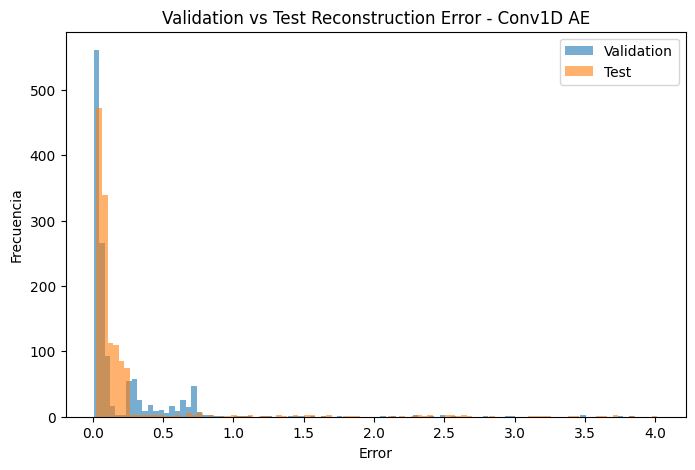

In [26]:
plt.figure(figsize=(8,5))
plt.hist(val_reconstruction_errors, bins=100, alpha=0.6, label="Validation")
plt.hist(test_reconstruction_errors, bins=100, alpha=0.6, label="Test")
plt.title("Validation vs Test Reconstruction Error - Conv1D AE")
plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()